In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


In [4]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape)
print(y_train.shape)

(60000, 28, 28)
(60000,)


In [5]:
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42
)

print("Training:", x_train.shape)
print("Validation:", x_val.shape)

Training: (48000, 28, 28)
Validation: (12000, 28, 28)


In [6]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

In [7]:

input_img = Input(shape=(28,28,1))


x = Conv2D(32,(3,3),activation='relu',padding='same')(input_img)
x = MaxPooling2D((2,2),padding='same')(x)

x = Conv2D(16,(3,3),activation='relu',padding='same')(x)
encoded = MaxPooling2D((2,2),padding='same')(x)


x = Conv2D(16,(3,3),activation='relu',padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32,(3,3),activation='relu',padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(
    1,
    (3,3),
    activation='sigmoid',
    padding='same'
)(x)

autoencoder = Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
autoencoder.compile(
    optimizer='adam',
    loss='mse'
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_autoencoder.keras",
    save_best_only=True,
    monitor='val_loss'
)


In [9]:
history = autoencoder.fit(

    x_train_noisy,
    x_train,

    epochs=20,

    batch_size=128,

    shuffle=True,

    validation_data=(x_test_noisy, x_test),

    callbacks=[early_stop, checkpoint]

)


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 85s 223ms/step - loss: 7223.2202 - val_loss: 7342.9526
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - loss: 7222.3179 - val_loss: 7342.8809
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 222ms/step - loss: 7222.2778 - val_loss: 7342.8550
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 218ms/step - loss: 7222.2588 - val_loss: 7342.8481
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 216ms/step - loss: 7222.2461 - val_loss: 7342.8257
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 82s 216ms/step - loss: 7222.2412 - val_loss: 7342.8198
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 221ms/step - loss: 7222.2319 - val_loss: 7342.8135
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 217ms/step - loss: 7222.2212 - val_loss: 7342.8071
Epoch 9/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 215ms/step - loss: 7222.2192 - val_loss: 7342.8042
Epoch 10/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 84s 220ms/step - loss: 7222.2173 - val_loss: 7342.8022
Epoch 11/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 215m

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


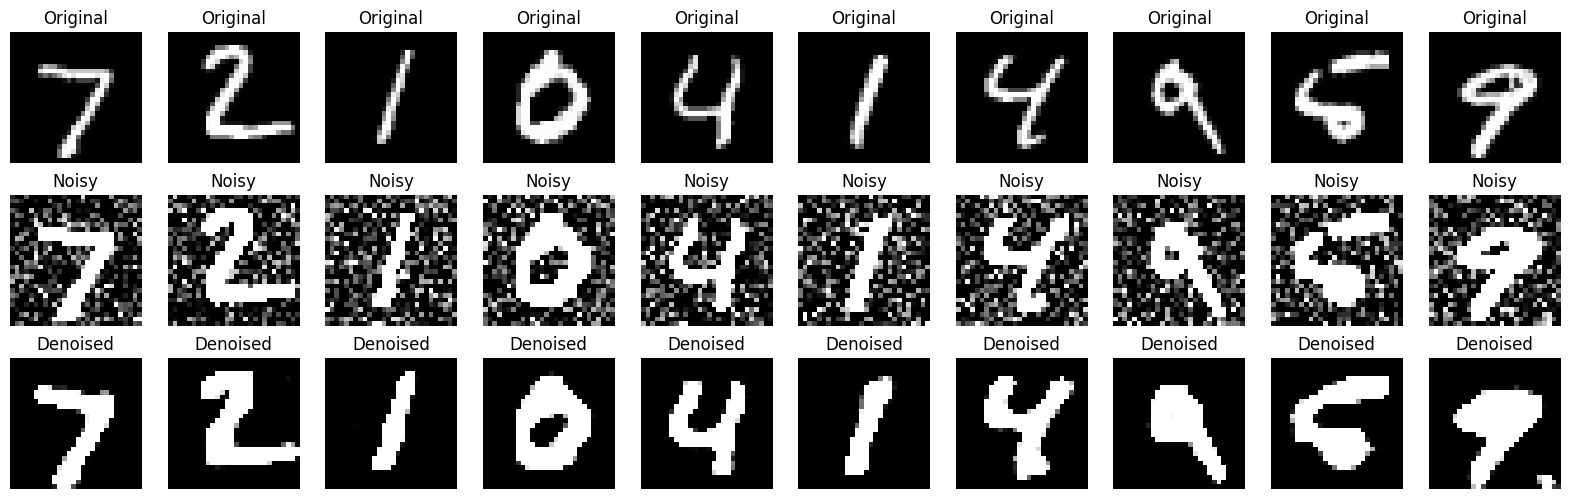

In [10]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10

plt.figure(figsize=(20,6))

for i in range(n):



    ax = plt.subplot(3,n,i+1)

    plt.imshow(x_test[i].reshape(28,28), cmap='gray')

    plt.title("Original")

    plt.axis("off")




    ax = plt.subplot(3,n,i+n+1)

    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')

    plt.title("Noisy")

    plt.axis("off")




    ax = plt.subplot(3,n,i+2*n+1)

    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')

    plt.title("Denoised")

    plt.axis("off")

plt.show()

In [11]:
autoencoder.save("MNIST_Denoising_Autoencoder.keras")

print("\nModel Saved Successfully!")

test_loss = autoencoder.evaluate(
    x_test_noisy,
    x_test,
    verbose=0
)

print("\nTest Loss :", test_loss)


Model Saved Successfully!

Test Loss : 7342.78662109375
